In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.metrics import classification_report

In [10]:
eurosat = load_dataset("blanchon/EuroSAT_RGB")

print(eurosat['train'])
print(eurosat['test'])
print(eurosat['validation'])

X_train = np.array(eurosat['train']['image']) / 255.0  # Normalizar
y_train = np.array(eurosat['train']['label'])

X_test = np.array(eurosat['test']['image']) / 255.0
y_test = np.array(eurosat['test']['label'])

X_validation = np.array(eurosat['validation']['image']) / 255.0
y_validation = np.array(eurosat['validation']['label'])

class_names = eurosat['train'].features['label'].names

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de X_validation:", X_validation.shape)

# Convertir las etiquetas a formato one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)
y_validation = to_categorical(y_validation, 10)

Dataset({
    features: ['image', 'label', 'filename'],
    num_rows: 16200
})
Dataset({
    features: ['image', 'label', 'filename'],
    num_rows: 5400
})
Dataset({
    features: ['image', 'label', 'filename'],
    num_rows: 5400
})
Tamaño de X_train: (16200, 64, 64, 3)
Tamaño de X_test: (5400, 64, 64, 3)
Tamaño de X_validation: (5400, 64, 64, 3)


In [11]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    Flatten(), #Se aplana para conectar con la capa densa
    Dense(128, activation='relu'), #Capa totalmente conectada con 128 neuronas
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_validation, y_validation))

c:\Users\Natalia\Desktop\Universidad7\Deep-Learning\2\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.4112 - loss: 1.5394 - val_accuracy: 0.5909 - val_loss: 1.1816
Epoch 2/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.6156 - loss: 1.0950 - val_accuracy: 0.6572 - val_loss: 0.9614
Epoch 3/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.6761 - loss: 0.9212 - val_accuracy: 0.7165 - val_loss: 0.7820
Epoch 4/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.7052 - loss: 0.8330 - val_accuracy: 0.7511 - val_loss: 0.6943
Epoch 5/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.7411 - loss: 0.7282 - val_accuracy: 0.7563 - val_loss: 0.6760
Epoch 6/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.7626 - loss: 0.6726 - val_accuracy: 0.7793 - val_loss: 0.6280
Epoch 7/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.7753 - loss: 0.6342 - val_accuracy: 0.8000 - val_loss: 0.5641
Epoch 8/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.8022 - loss: 0.5702 - 

Exactitud en el conjunto de prueba: 0.86


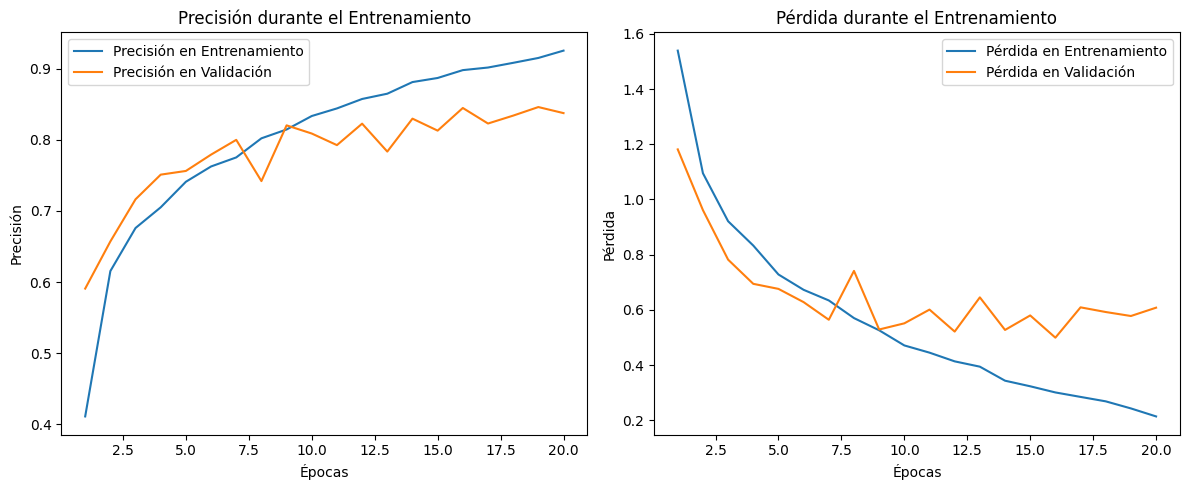

In [12]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Exactitud en el conjunto de prueba: {test_acc:.2f}")

# Graficar la precisión y la pérdida del entrenamiento
epochs = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(12, 5))

# Gráfico de la precisión
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], label='Precisión en Entrenamiento')
plt.plot(epochs, history.history['val_accuracy'], label='Precisión en Validación')
plt.title('Precisión durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# Gráfico de la pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], label='Pérdida en Entrenamiento')
plt.plot(epochs, history.history['val_loss'], label='Pérdida en Validación')
plt.title('Pérdida durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test = np.argmax(y_test, axis=1)

169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [14]:
val_loss, val_acc = model.evaluate(X_validation, y_validation, verbose=0)
print(f"Exactitud en el conjunto de validación: {val_acc:.2f}")

classification_report_str = classification_report(y_test, y_pred_classes, target_names=class_names)
print("Reporte de Clasificación:\n", classification_report_str)

Exactitud en el conjunto de validación: 0.84
Reporte de Clasificación:
                        precision    recall  f1-score   support

          Annual Crop       0.86      0.90      0.88       596
               Forest       0.90      0.99      0.94       608
Herbaceous Vegetation       0.83      0.74      0.79       573
              Highway       0.74      0.72      0.73       496
 Industrial Buildings       0.97      0.85      0.91       501
              Pasture       0.87      0.83      0.85       396
       Permanent Crop       0.79      0.71      0.75       538
Residential Buildings       0.80      1.00      0.89       554
                River       0.82      0.81      0.81       529
              SeaLake       0.98      0.98      0.98       609

             accuracy                           0.86      5400
            macro avg       0.86      0.85      0.85      5400
         weighted avg       0.86      0.86      0.86      5400



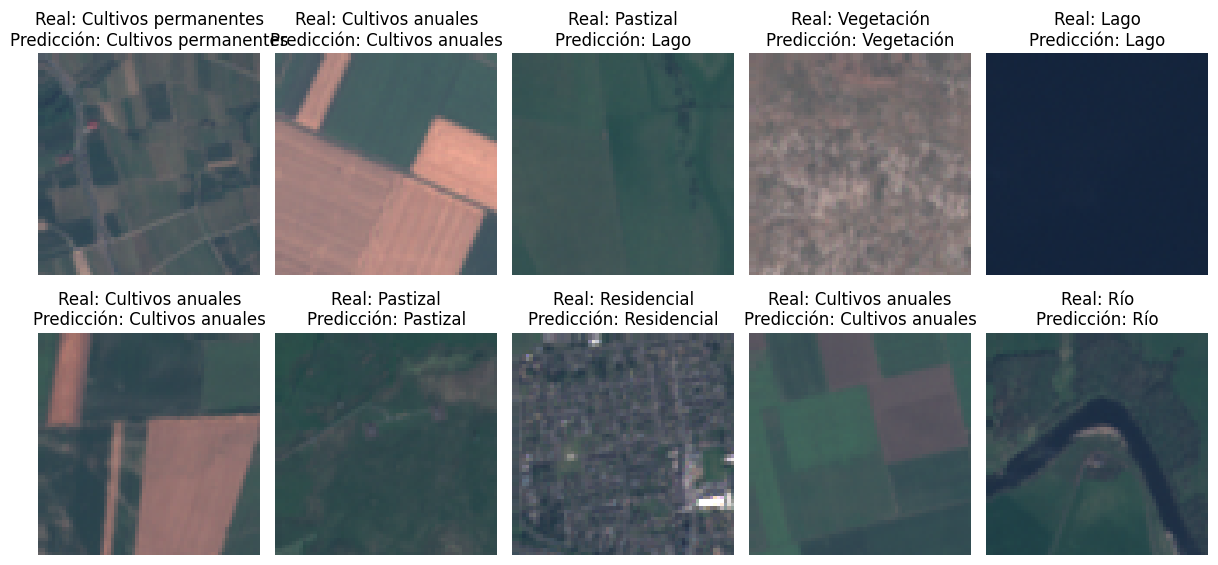

In [15]:
#print("clases de prueba", np.argmax(y_test,axis=1))

# Diccionario de clases para Fashion MNIST
class_names = ['Cultivos anuales', 'Bosque', 'Vegetación', 'Carretera', 'Industrial', 'Pastizal', 'Cultivos permanentes', 'Residencial', 'Río', 'Lago']
#print(f"Real: {class_names[int(y_test[1][0])]}\nPredicción: {class_names[y_pred_classes[1]]}")

idx = np.random.choice(len(X_test), 10, replace=False)

# Mostrar las primeras 10 imágenes del conjunto de prueba junto con sus predicciones
plt.figure(figsize=(12, 6))
for i, j in enumerate(idx):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[j])
    plt.title(f"Real: {class_names[y_test[j]]}\nPredicción: {class_names[y_pred_classes[j]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()